In [1]:
import ase.units as units
from ase.build import molecule
from ase.calculators.tip3p import TIP3P
from ase.constraints import FixBondLengths
from ase.io.trajectory import Trajectory
from ase.md import Langevin

import matplotlib.pyplot as plt 
from ase.visualize.plot import plot_atoms 
from ase.io import read, write

import numpy as np

In [3]:
# initialise and equilibrate water box 
water_molecules = molecule('H2O') # creating water molecule
density = 0.9982  # denisty of water in g/cm^3 at 20°C
box_length = ((water_molecules.get_masses().sum() / units.mol) / (density * 1e-24)) ** (
    1 / 3
)  # box length in Å
water_molecules.set_cell((box_length, box_length, box_length))
water_molecules.center()
# Repeat the water molecule we just created to end up with a PBC cell
water_molecules *= (3, 3, 3)
water_molecules.set_pbc(True)

water_molecules.constraints = FixBondLengths(
    [(3 * i + j, 3 * i + (j + 1) % 3) for i in range(3**3) for j in [0, 1, 2]]
)
# RATTLE-type constraints on O-H1, O-H2, H1-H2.
tag = 'tip3p_27mol_equil'
water_molecules.calc = TIP3P(rc=4.5)  # set the calculator to be the TIP3P force field

# Equillibrate in a small box first.
md = Langevin(
    water_molecules,
    1 * units.fs,
    temperature_K=293.15,  # 20 °C
    friction=0.01,
    logfile=tag + '.log',
)

traj = Trajectory(tag + '.traj', 'w', water_molecules)
md.attach(traj.write, interval=1)
md.run(4)  # please use 4000 to better equilibrate

# Repeat box and equilibrate further.
tag = 'tip3p_216mol_equil'
water_molecules.set_constraint()  # repeat not compatible with FixBondLengths currently.
water_molecules *= (2, 2, 2)
water_molecules.constraints = FixBondLengths(
    [
        (3 * i + j, 3 * i + (j + 1) % 3)
        for i in range(len(water_molecules) // 3)
        for j in [0, 1, 2]
    ]
)
water_molecules.calc = TIP3P(rc=7.0)

md = Langevin(
    water_molecules,
    2 * units.fs,
    temperature_K=293.15,  # 20 °C
    friction=0.01,
    logfile=tag + '.log',
)

traj = Trajectory(tag + '.traj', 'w', water_molecules)
md.attach(traj.write, interval=1)
md.run(2)  # please use 2000 to better equilibrate

write('tip3p_equilibrated.traj', water_molecules)


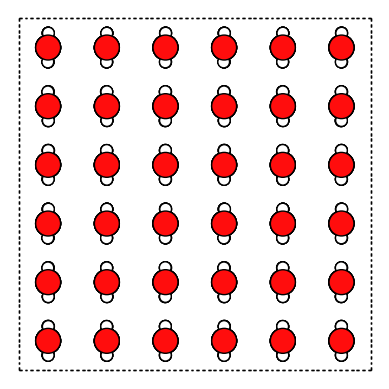

In [2]:
water_molecules = read('tip3p_equilibrated.traj')
fig, ax = plt.subplots()
plot_atoms(water_molecules, ax)
ax.set_axis_off()

Running water MD with TIP3P

running a NVE simulation of equilibrated water 
Energy per atom: Epot =40.449eV  Ekin = 16.670eV (T=298.522K) Etot = 57.118eV
Energy per atom: Epot =40.204eV  Ekin = 16.914eV (T=302.906K) Etot = 57.119eV
Energy per atom: Epot =39.470eV  Ekin = 17.650eV (T=316.086K) Etot = 57.120eV
Energy per atom: Epot =38.115eV  Ekin = 19.008eV (T=340.401K) Etot = 57.123eV
Energy per atom: Epot =35.933eV  Ekin = 21.193eV (T=379.530K) Etot = 57.126eV
Energy per atom: Epot =32.670eV  Ekin = 24.457eV (T=437.989K) Etot = 57.128eV
Energy per atom: Epot =28.087eV  Ekin = 29.040eV (T=520.050K) Etot = 57.126eV
Energy per atom: Epot =22.050eV  Ekin = 35.070eV (T=628.048K) Etot = 57.120eV
Energy per atom: Epot =14.639eV  Ekin = 42.469eV (T=760.551K) Etot = 57.108eV
Energy per atom: Epot = 6.197eV  Ekin = 50.894eV (T=911.424K) Etot = 57.091eV
Energy per atom: Epot =-2.709eV  Ekin = 59.780eV (T=1070.558K) Etot = 57.071eV
Energy per atom: Epot =-11.411eV  Ekin = 68.463eV (T=1226.052K) Etot = 57.052eV
Energy per at

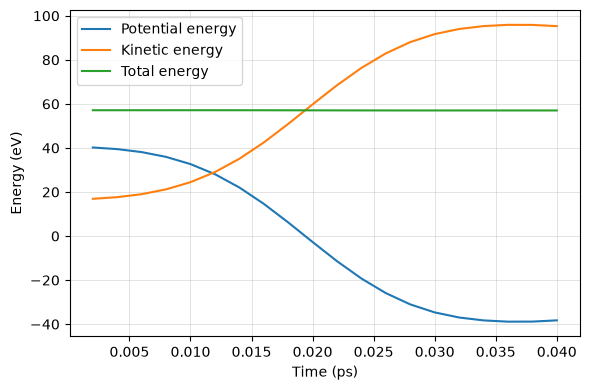

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# choose one of the following implementations of EMT:
# included in ase
# from ase.calculators.emt import EMT
# faster performance
from asap3 import EMT
from ase.calculators.tip4p import TIP3P
from ase import units

from ase.io.trajectory import Trajectory

from ase.md.velocitydistribution import (
    MaxwellBoltzmannDistribution,
    Stationary,
    ZeroRotation,
)
from ase.md.verlet import VelocityVerlet
from ase.optimize import QuasiNewton
from ase.visualize.plot import plot_atoms


# Describe the interatomic interactions with the Effective Medium Theory (EMT)
water_molecules.calc = TIP3P()

# Set the initial velocities corresponding to T=300K from Maxwell Boltzmann
# Distribution
MaxwellBoltzmannDistribution(water_molecules, temperature_K=300)


timestep_fs = 1
dyn = VelocityVerlet(water_molecules, timestep_fs * units.fs)  # 1 fs time step.

def printenergy(a):
    """
    Function to print the thermodynamical properties i.e potential energy,
    kinetic energy and total energy
    """
    epot = a.get_potential_energy()
    ekin = a.get_kinetic_energy()
    temp = a.get_temperature()
    print(
        f'Energy per atom: Epot ={epot:6.3f}eV  Ekin = {ekin:.3f}eV '
        f'(T={temp:.3f}K) Etot = {epot + ekin:.3f}eV'
    )

# Now run the dynamics
print('running a NVE simulation of equilibrated water ')
printenergy(water_molecules)
# init lists to for energy vs time data
time_ps, epot, ekin = [], [], []
mdind = 0
steps_per_block = 2
for i in range(20):
    dyn.run(steps_per_block)
    mdind += steps_per_block
    printenergy(water_molecules)
    # save the energies of the current MD step
    time_ps.append(mdind * timestep_fs / 1000.0)
    epot.append(water_molecules.get_potential_energy())
    ekin.append(water_molecules.get_kinetic_energy())

etot = np.array(epot) + np.array(ekin)

# Plot energies vs time
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(time_ps, epot, label='Potential energy')
ax.plot(time_ps, ekin, label='Kinetic energy')
ax.plot(time_ps, etot, label='Total energy')
ax.set_xlabel('Time (ps)')
ax.set_ylabel('Energy (eV)')
ax.legend(loc='best')
ax.grid(True, linewidth=0.5, alpha=0.5)
plt.tight_layout()

plt.savefig('waterMD.png')
plt.show()


Creating custom calculator

In [7]:
from ase.calculators.calculator import Calculator, all_changes 

class MLPCalculator(Calculator):
    implemented_properties = ['energy', 'forces']

    def calculate(self, atoms=None, properties=['energy','forces'], system_changes=all_changes):
        super().calculate(atoms, properties, system_changes)
        self.results = dict()
        if atoms is not None:
            energy_per_atom = self.parameters.get('energy_per_atom', 0.0)
            self.results = {
                'energy': energy_per_atom * len(atoms),
                'forces': np.zeros((len(atoms), 3)),
            }

def get_calculator(energy_per_atom: float = 0.0):
    return MLPCalculator(energy_per_atom=energy_per_atom)

def example():
    from ase.build import molecule

    atoms = molecule("H2O")
    atoms.calc = get_calculator(energy_per_atom=1.0)

    energy = atoms.get_potential_energy()
    forces = atoms.get_forces()

    print(f"Energy of water molecule: {energy:.3f} eV")
    print(f"Forces (eV/ang): {forces}")


In [ ]:
example()

NameError: name 'example' is not defined